###### ♦ Name :- Jagadish

# EDA on Netflix Data

### ○ Plot a pie chart to check how the content on Netflix is available by “Type” in data.

### ○ Plot the top 10 countries with highest number of content (Movies & TV Show combined)

### ○ Using countplot in sns library, find out in which year was the highest content added for Movies & TV shows both and write a summary on what is observed from this chart.

### ○ Derive & plot the content rating by “rating_ages” & which is the leading content rating category?

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading The Dataset

In [2]:
netflix = pd.read_csv("netflix_titles.csv")

# View of Data
netflix

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


### Data Preparation and Cleaning

In [3]:
# Basic information of the dataset
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


Insight : The Dataset contains over 7787 entries and 12 descriptions.

### Checking Missing Values

<AxesSubplot:>

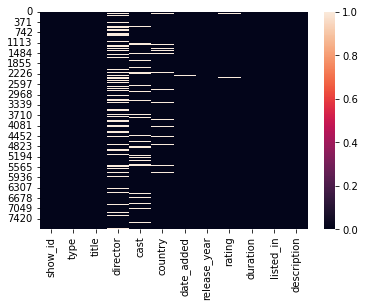

In [4]:
# Visual View
sns.heatmap(netflix.isnull())

In [5]:
# View Missing Values
netflix.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

Insight : There are a few columns that contain null values, that are "director" has 2389, "cast" has 718, "country" has 507, "date_added" has 10 and "rating" has 7 respectively.

### Handling Missing Values

In [6]:
# Filling Missing Values in "director" Column
netflix.director.fillna("No Director", inplace=True)

# Filling Missing Values in "cast" Column
netflix.cast.fillna("No Cast", inplace=True)

# Filling Missing Values in "country" Column
netflix.country.fillna("Country Unavailable", inplace=True)

Since “director”, “cast” and “country” contain the majority of null values, So I chose to treat each missing value is unavailable.

In [7]:
# droping nan values from "date_added" and "rating"
netflix.dropna(subset=["date_added", "rating"], inplace=True)

The other two columns “date_added” and “rating” contain an insignificant portion of the data, so we can drop nan values from the dataset.

### Again Checking Missing Values

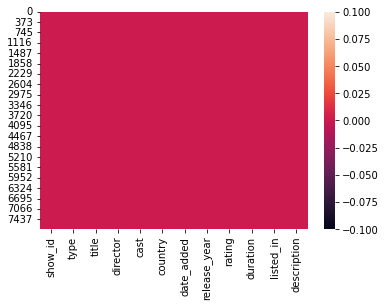

In [8]:
sns.heatmap(netflix.isnull())
plt.show()

In [9]:
# View in numbers
netflix.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Finally, we can see that there are no more missing values in the data frame.

## Exploratory Analysis and Visualization

### Checking how the content on Netflix is available by “Type” (Movies or TV Shows) in data.

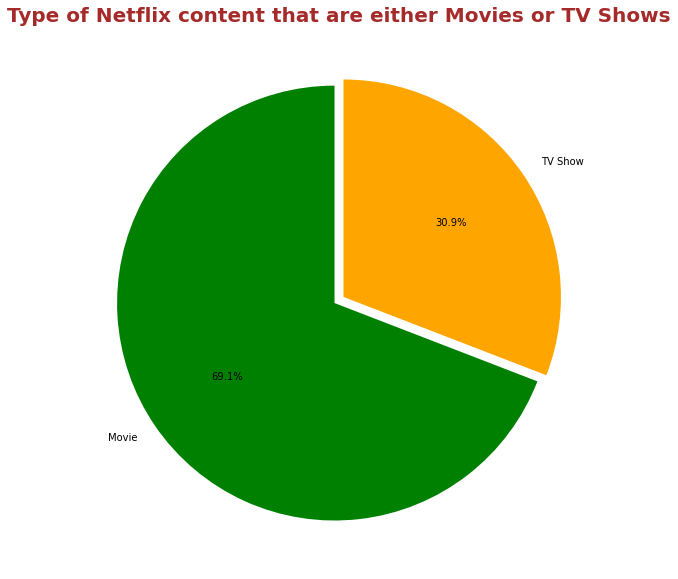

In [10]:
plt.figure(figsize=(10,10))
plt.title("Type of Netflix content that are either Movies or TV Shows", 
          fontweight='bold', 
          fontsize=20, 
          color='brown')

g = plt.pie(netflix.type.value_counts(),
            explode=(0.025,0.025), 
            labels=netflix.type.value_counts().index, colors=['green', 'orange'], 
            autopct='%1.1f%%', 
            startangle=90)

plt.show()

#### Insight : 

♦ Chart shows there are 69.1% Movies and 30.9% TV Shows in Netflix Dataset. Movie contains high values and TV Show contains low values.

### Top 10 Countries with highest number of content (Movies & TV show combined)

top_10_country = netflix['country'].value_counts()
top_10_country = top_10_country[top_10_country != 'Country Unavailable']
plt.figure(figsize=(16,6))
sns.barplot(top_10_country.values[:10], top_10_country.index[:10])
plt.show()

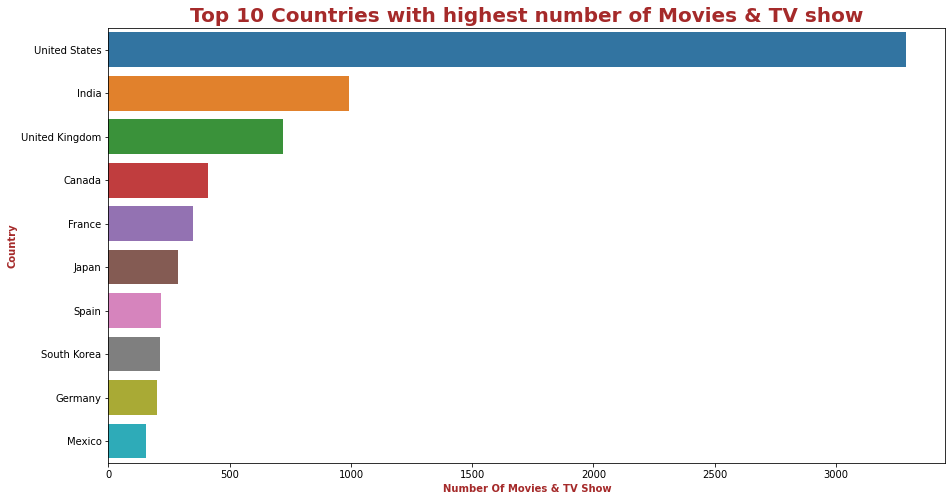

In [11]:
top_10_country = netflix.set_index('title').country.str.split(', ', expand=True).stack().reset_index(level=1, drop=True);
top_10_country = top_10_country[top_10_country != 'Country Unavailable']

plt.figure(figsize=(15,8))

g = sns.countplot(y = top_10_country, order=top_10_country.value_counts().index[:10])
plt.title("Top 10 Countries with highest number of Movies & TV show",
         fontweight='bold', fontsize=20, color='brown')

plt.xlabel("Number Of Movies & TV Show", fontweight='bold', fontsize=10, color='brown')
plt.ylabel('Country', fontweight='bold', fontsize=10, color='brown')

plt.show()

#### Insight : As can see top 10 countries with highest number of Movies & TV show combined are:-
                    
                    ♦ 1  : United States
                    ♦ 2  : India
                    ♦ 3  : United Kingdom
                    ♦ 4  : Canada
                    ♦ 5  : France
                    ♦ 6  : Japan
                    ♦ 7  : Spain
                    ♦ 8  : South Korea
                    ♦ 9  : Germany
                    ♦ 10 : Mexico

### Which year was the highest content added for Movies & TV shows?

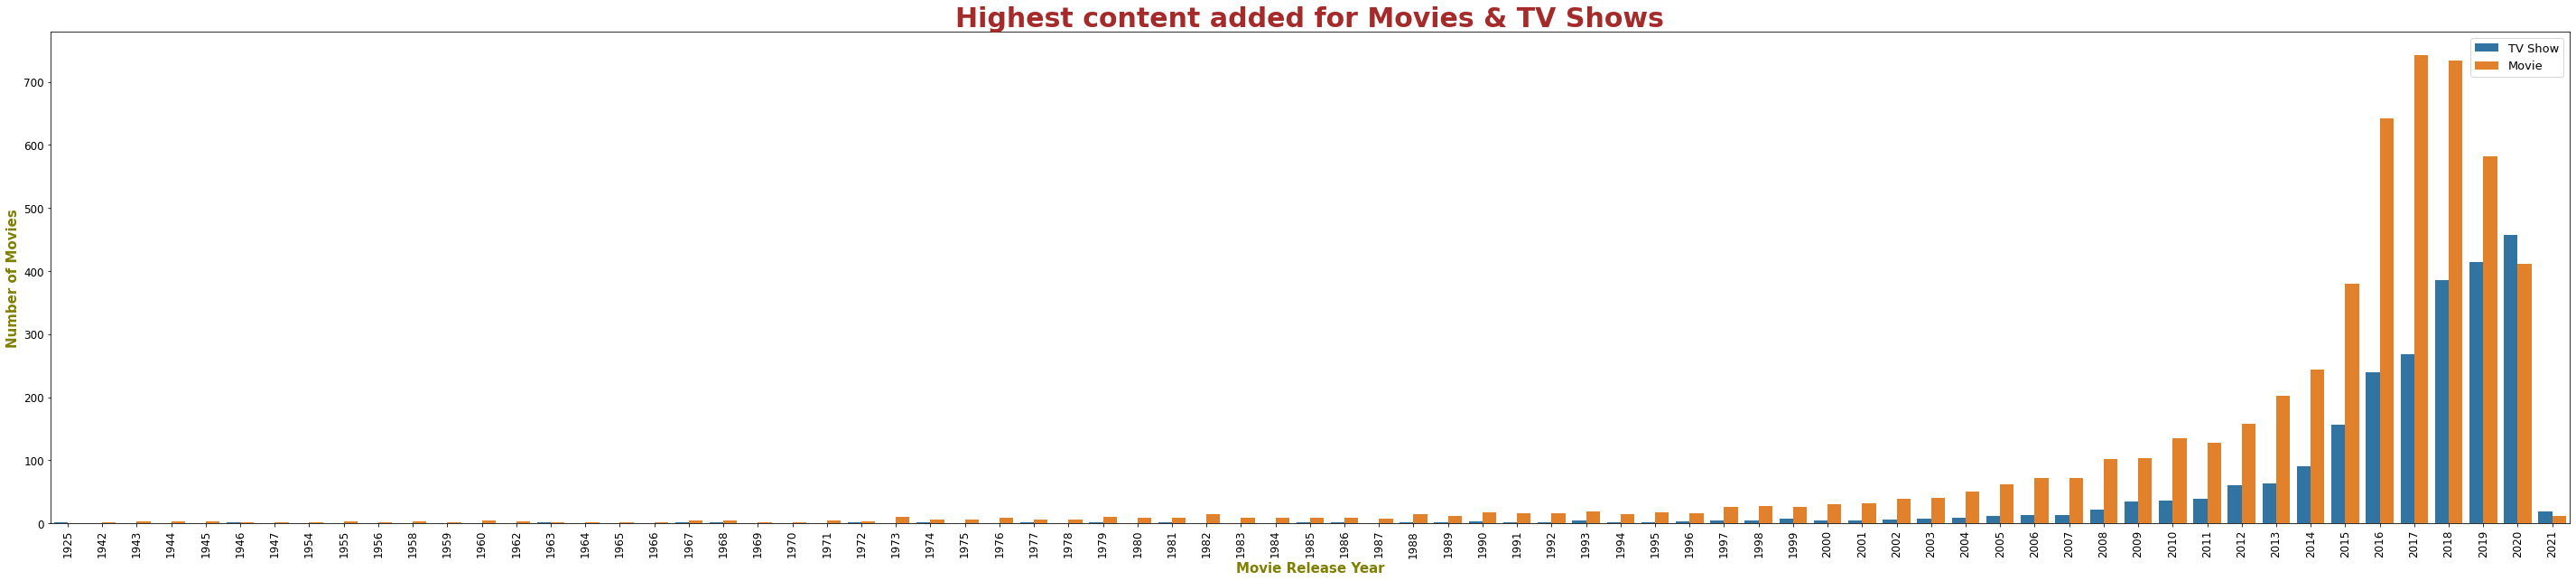

In [12]:
plt.figure(figsize=(50,10))

sns.countplot(x='release_year', hue='type', data=netflix)
plt.title("Highest content added for Movies & TV Shows", fontsize=30, fontweight='bold', color='brown')
plt.xlabel("Movie Release Year", fontsize=15, fontweight='bold', color='olive')
plt.ylabel("Number of Movies", fontsize=15, fontweight='bold', color='olive')
plt.legend(loc=1, prop={'size': 13})
plt.tick_params(labelsize=12)
plt.xticks(rotation=90)

plt.show()

#### Insight :

            ♦ Year 2017 was the highest content added for Movies and Year 2020 was the highest content added for TV shows.

            ♦ Data says that maximum people used to watch Movies till 2017 and from year 2017 it is gently declining now.


            Future :

                    ♦ Data says that now people love to watch TV Shows more than watching Movies.

                    ♦ Invest in TV Shows content will return high benefit.


### Derive & plot the content rating by “rating_ages” & which is the leading content rating category?

In [13]:
# Unique Values
print(netflix['rating'].unique())

['TV-MA' 'R' 'PG-13' 'TV-14' 'TV-PG' 'NR' 'TV-G' 'TV-Y' 'TV-Y7' 'PG' 'G'
 'NC-17' 'TV-Y7-FV' 'UR']


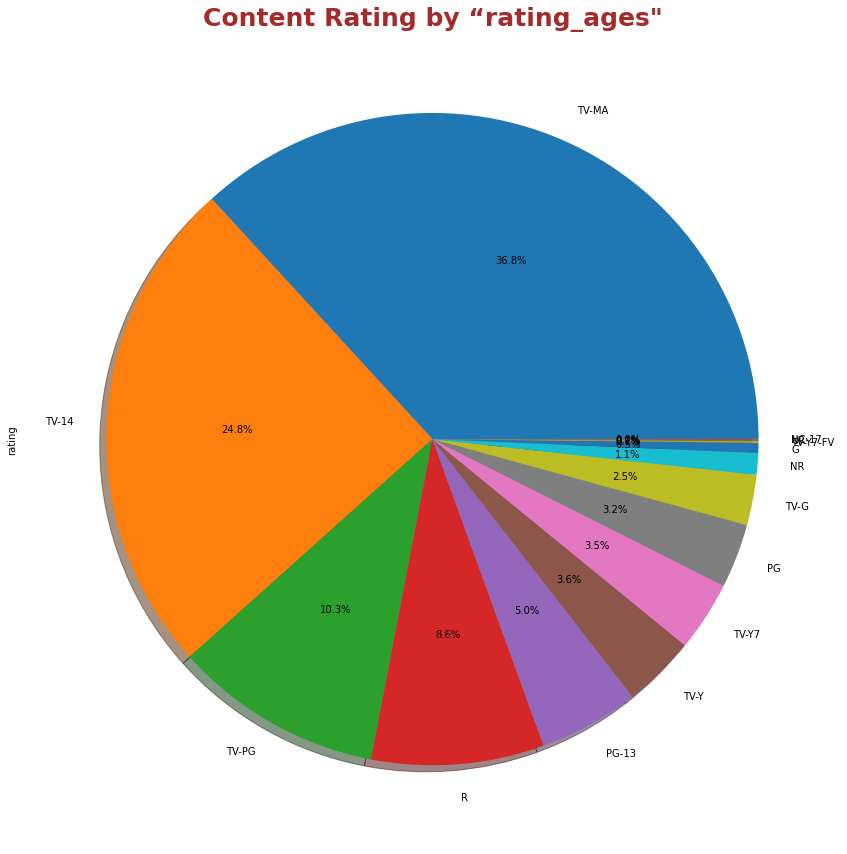

In [14]:
netflix['rating'].value_counts().plot.pie(autopct='%1.1f%%',shadow=True,figsize=(25,15))
plt.title('Content Rating by “rating_ages"',
         fontweight='bold', fontsize=25, color='brown')
plt.show()

#### Insight : 

            ♦ "TV-MA" contains 36.8% rating and It is the leading content rating category.

♦ "TV-14" contains 24.8% rating and It is second largest content rating category and third one is "TV-PG" contains 10.3% and so on.

                                                 ••••••○○○○○○••••••